# Optogenetics — Visualization

This notebook loads the previously built combined DataFrame (see `optogenetics_build_dataframe.ipynb`) and runs the visualization / exploration workflows.

In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [2]:
from nwb_utils import NWBUtils
from optogenetics_utils import (
    create_opto_data_frame,
    find_unique_combinations,
    find_unique_stimulation,
    load_opto_data_frame,
    find_unique_values_by_conditions,
    normalize_string_columns,
    create_opto_data_frame_combined
)
from optogenetics_visualization import (
    plot_stay_switch_over_window,
    plot_rates_vs_latent,
    plot_on_off_block_rates,
    plot_lick_raster_over_window,
)

## Load the pre-built combined DataFrame

In [3]:
combined_dataframe = load_opto_data_frame(
    csv_path='/root/capsule/scratch/combined_opto_data_frame.csv'
)
combined_dataframe = normalize_string_columns(combined_dataframe)
combined_dataframe.shape

(112033, 133)

In [4]:

combined_dataframe_o=load_opto_data_frame(csv_path = '/root/capsule/scratch/combined_opto_data_frame.csv')

combined_dataframe=create_opto_data_frame_combined(save_path='/root/capsule/scratch/combined_opto_data_frame.csv',existing_data=combined_dataframe_o)

Skipping 183 NWB file(s) already present in existing_data.


Processing NWB files: 0file [00:00, ?file/s]

Combined DataFrame saved to /root/capsule/scratch/combined_opto_data_frame.csv


## Inspect unique stimulation conditions

In [4]:
find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    #include={"laser_1_target_areas":["left VP GABAergic neuron inactivation"],"laser_2_target_areas":["right VP GABAergic neuron inactivation"]}

    #include={"laser_1_target_areas":["left VP GABAergic neuron inactivation"],"laser_2_target_areas":["right VP GABAergic neuron inactivation"]}

    #include={"laser_1_target_areas":["left VP Glutamatergic neuron"],"laser_2_target_areas":["right VP Glutamatergic neuron"]}
    

    
)

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,...,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left MD inactivation,right MD inactivation,NaN,20445,50,7
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left ALM inactivation,right ALM inactivation,NaN,19674,51,6
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,NaN,NaN,NaN,10070,20,5
3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,NaN,9574,22,9
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,8833,21,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1,473.0,laser_1,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,on,0.5,on,on,left VP Glutamatergic neuron stimulation,NaN,0.8,15,1,1
88,1,473.0,both,5.0,go cue,0.3,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,12,1,1
89,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,off,0.5,on,on,left MD inactivation,right MD inactivation,1.0,8,1,1
90,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,off,0.5,on,on,left MD inactivation,right MD inactivation,1.0,5,1,1


In [5]:
conds = {"laser_start": "Go cue", "laser_end": "Trial start"}
unique_vals = find_unique_values_by_conditions(combined_dataframe, conds, output_column="session")
print(unique_vals)

[]


In [6]:
combined_dataframe['laser_2_target_areas'].unique()

array([None, 'right ALM inactivation', 'right VP->MD stimulation',
       'right MD inactivation', 'right mPFC inactivation',
       'right VP GABAergic neuron inactivation',
       'right VP Glutamatergic neuron stimulation',
       'Right VP->MD GABAergic neuron stimulation'], dtype=object)

## Build a `criteria` dict from one stimulation row

In [21]:
import pandas as pd

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP Glutamatergic neuron stimulation"],
        "laser_2_target_areas": ["right VP Glutamatergic neuron stimulation"],
    },
)
'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP Glutamatergic neuron stimulation"],
        "laser_2_target_areas": ["right VP Glutamatergic neuron stimulation"],
    },
)


'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)
'''

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["Left VP->MD GABAergic neuron stimulation"],
        "laser_2_target_areas": ["Right VP->MD GABAergic neuron stimulation"],
    },
)
'''

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP->MD stimulation"],
        "laser_2_target_areas": ["right VP->MD stimulation"],
    },
)
'''

	

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)
'''

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left MD inactivation"],
        "laser_2_target_areas": ["right MD inactivation"],
    },
)
'''

conditions = conditions.sort_values(
    by=["laser_1_target_areas", "laser_2_target_areas", "session_wide_control", "n_trials"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

print(f"n conditions = {len(conditions)}")

ROW_POS = 4  # positional index (0-based) into the sorted conditions table
if ROW_POS >= len(conditions):
    raise IndexError(
        f"ROW_POS={ROW_POS} is out of range; only {len(conditions)} condition(s) matched. "
        f"Pick a value in 0..{len(conditions) - 1}."
    )

row = conditions.iloc[ROW_POS]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

n conditions = 5


{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 3.0,
 'laser_start': 'go cue',
 'laser_start_offset': 0.0,
 'laser_end': None,
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'on',
 'fraction_of_session': 0.5,
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP Glutamatergic neuron stimulation',
 'laser_2_target_areas': 'right VP Glutamatergic neuron stimulation'}

In [22]:
conditions

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,laser_pulse_duration,session_wide_control,fraction_of_session,session_alternation,laser_1_target_areas,laser_2_target_areas,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,on,0.5,on,left VP Glutamatergic neuron stimulation,right VP Glutamatergic neuron stimulation,8420,22,2
1,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,0.002,on,0.5,on,left VP Glutamatergic neuron stimulation,right VP Glutamatergic neuron stimulation,460,20,2
2,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,0.002,on,0.5,on,left VP Glutamatergic neuron stimulation,right VP Glutamatergic neuron stimulation,108,11,2
3,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,0.002,on,0.5,on,left VP Glutamatergic neuron stimulation,right VP Glutamatergic neuron stimulation,95,10,2
4,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,0.002,on,0.5,on,left VP Glutamatergic neuron stimulation,right VP Glutamatergic neuron stimulation,92,10,2


## Plot rates vs. a latent variable (ITI delay sum)

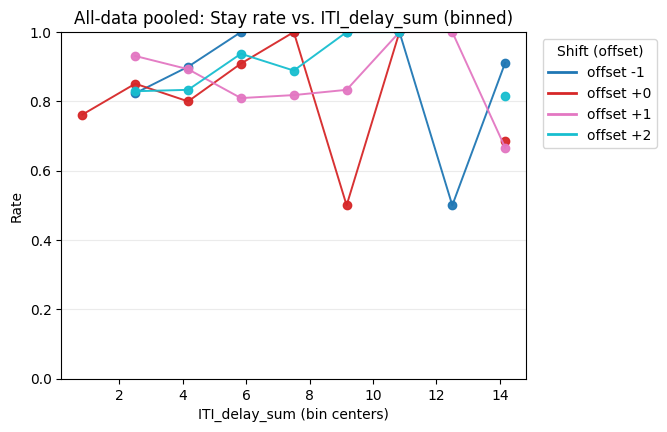

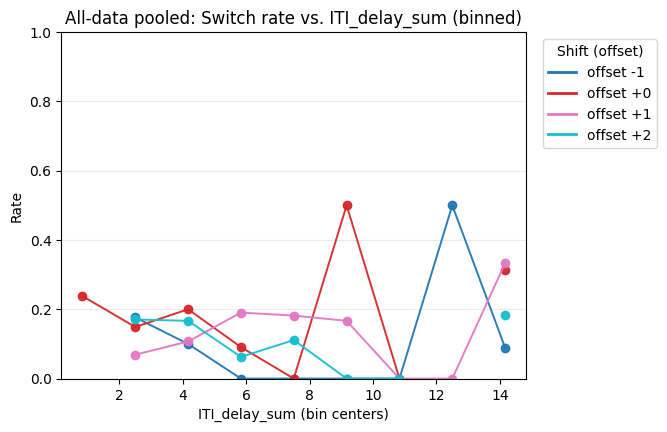

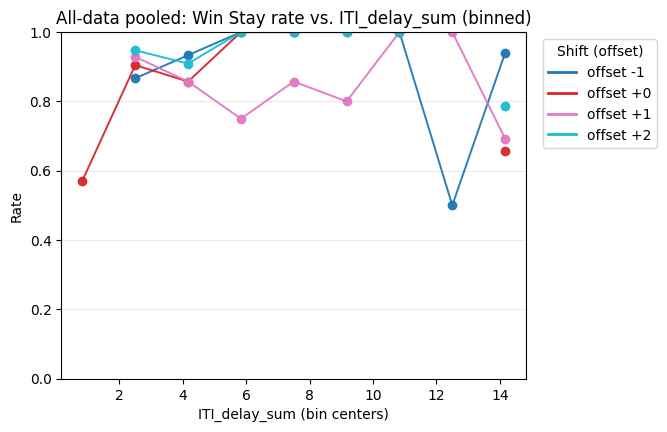

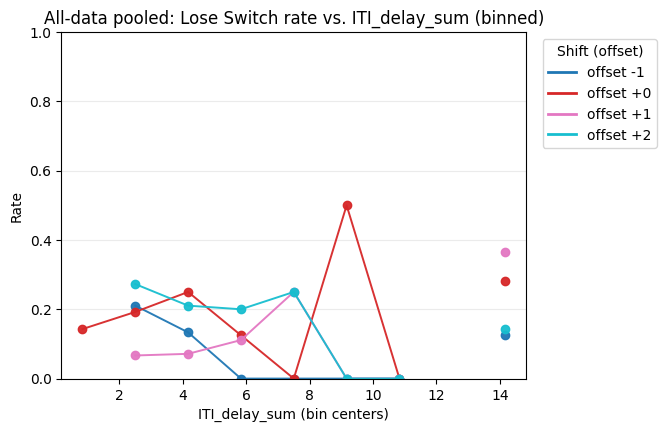

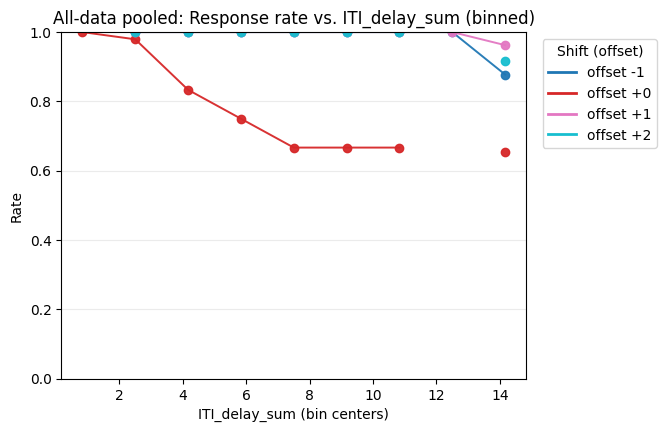

In [9]:
figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="ITI_delay_sum",
    line_by="all",
    bins=9,
    binning="uniform",
    criteria=criteria,
    latent_range=(0, 15),
    window=[-1, 2],
)

## Stay/switch over window + rates vs. deltaQ

In [23]:

row = conditions.loc[1]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 50.0,
 'laser_start': 'trial start',
 'laser_start_offset': 0.0,
 'laser_end': 'go cue',
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'on',
 'fraction_of_session': 0.5,
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP Glutamatergic neuron stimulation',
 'laser_2_target_areas': 'right VP Glutamatergic neuron stimulation'}

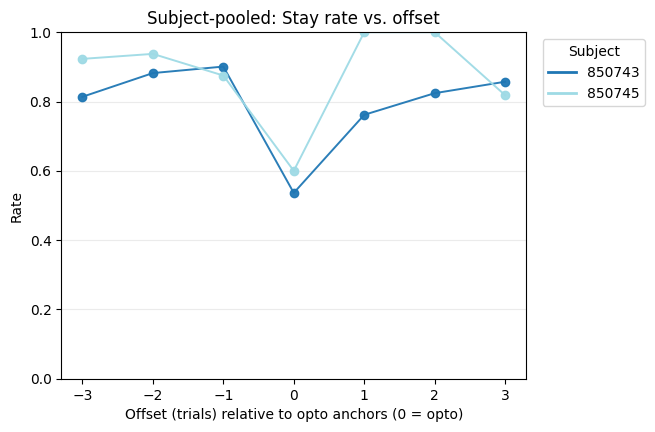

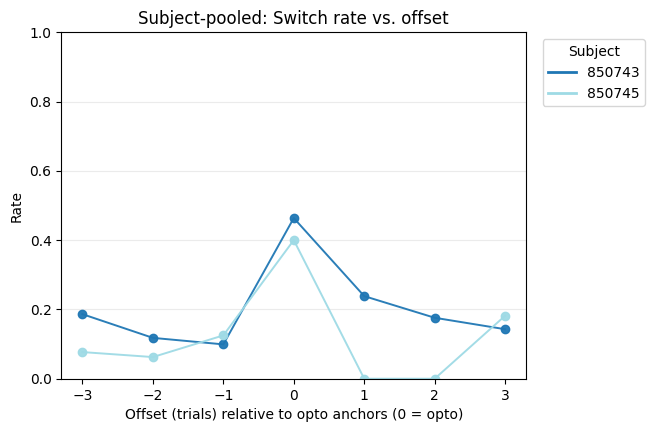

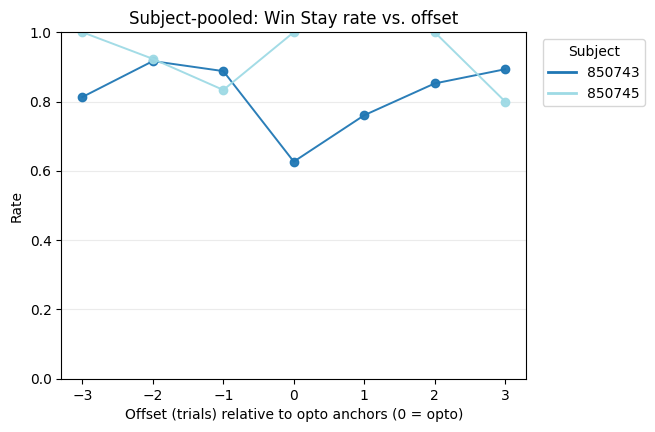

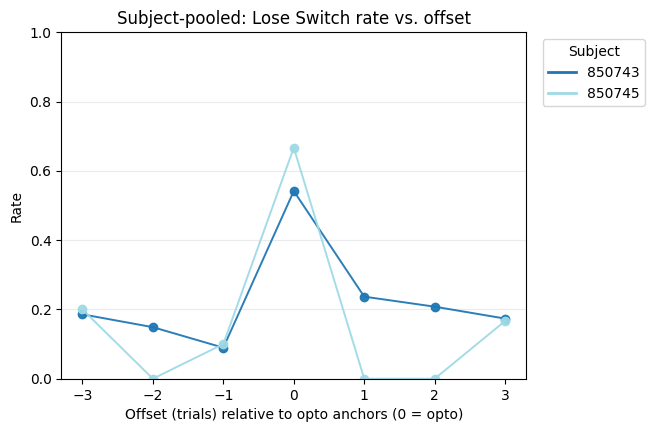

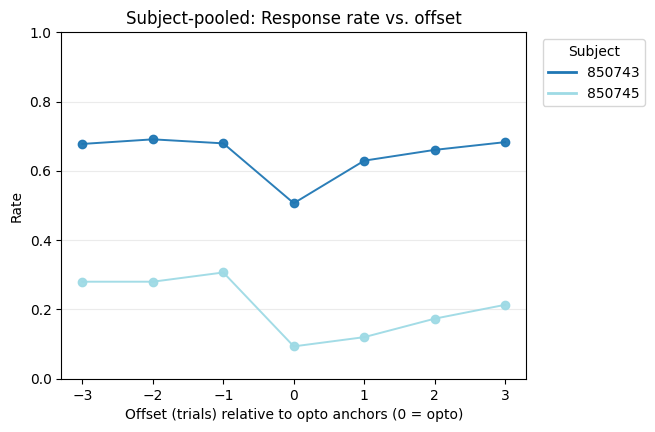

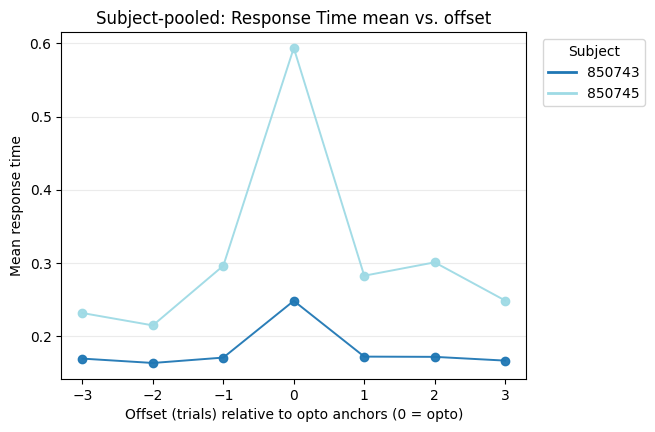

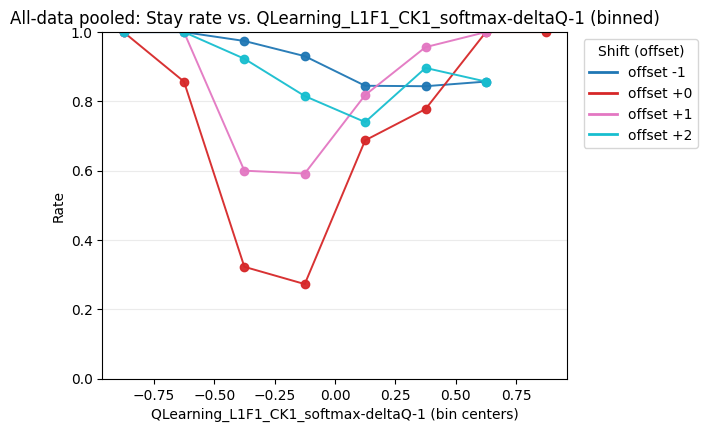

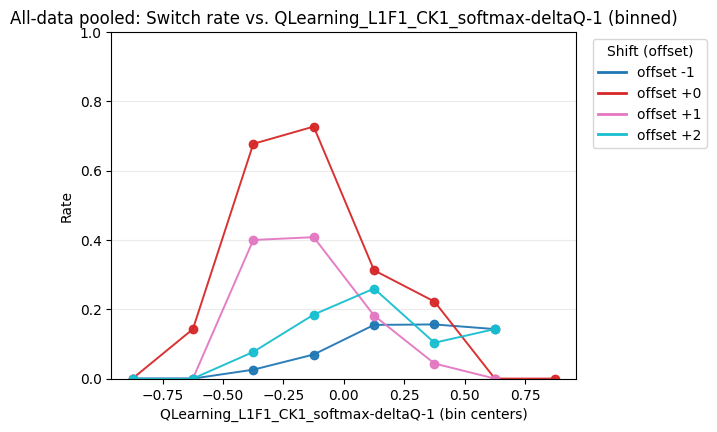

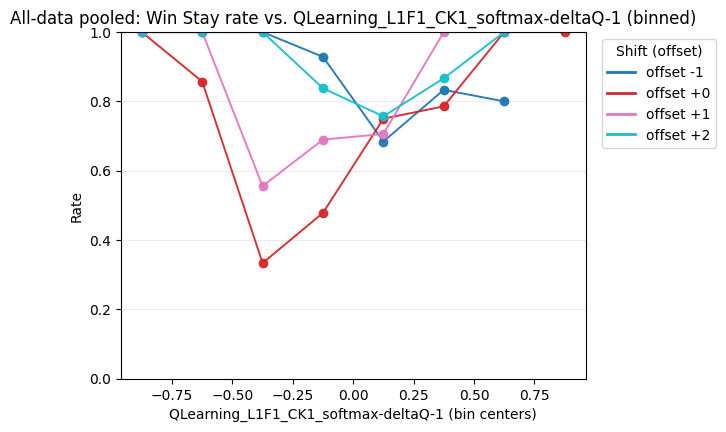

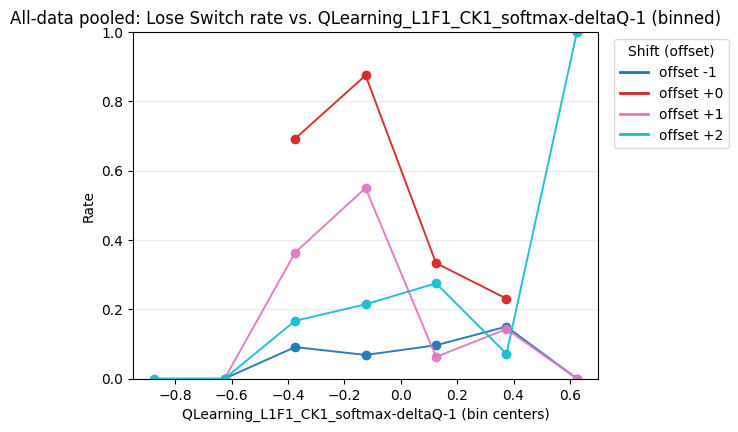

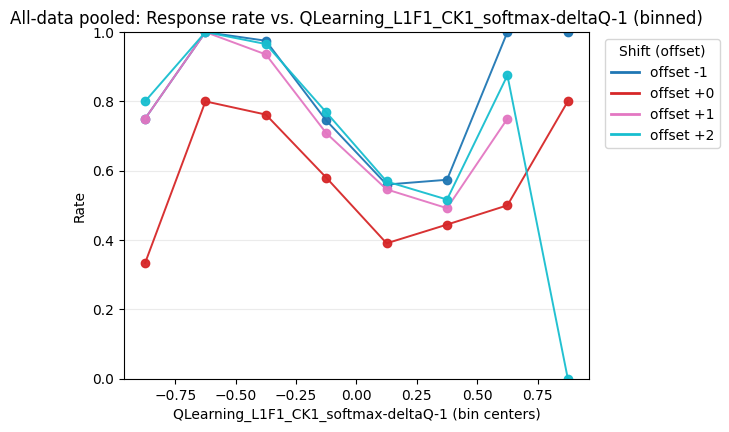

In [24]:
plot_stay_switch_over_window(
    combined_dataframe,
    criteria=criteria,
    window=[-3, 3],
    line_by='subject',
    #exclude={'subject_id':[779310,795396,795710]},
    max_response_time=1
)

figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="QLearning_L1F1_CK1_softmax-deltaQ-1",
    line_by="all",
    bins=8,
    binning="uniform",
    criteria=criteria,
    window=[-1, 2],
    #exclude={'subject_id':[844033,778149]}
)

In [26]:

row = conditions.loc[1]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 50.0,
 'laser_start': 'trial start',
 'laser_start_offset': 0.0,
 'laser_end': 'go cue',
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'on',
 'fraction_of_session': 0.5,
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP Glutamatergic neuron stimulation',
 'laser_2_target_areas': 'right VP Glutamatergic neuron stimulation'}

{'stay': <Figure size 500x450 with 1 Axes>,
 'switch': <Figure size 500x450 with 1 Axes>,
 'win_stay': <Figure size 500x450 with 1 Axes>,
 'lose_switch': <Figure size 500x450 with 1 Axes>,
 'response': <Figure size 500x450 with 1 Axes>,
 'response_time': <Figure size 500x450 with 1 Axes>}

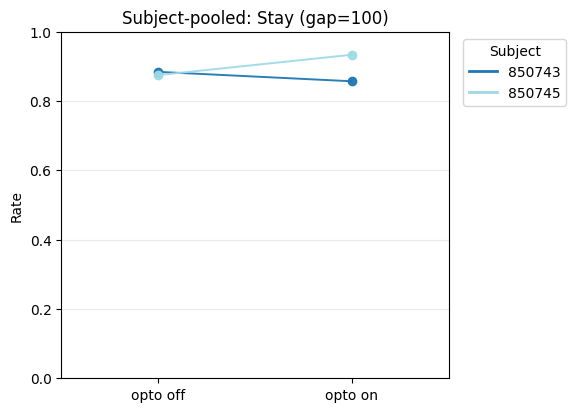

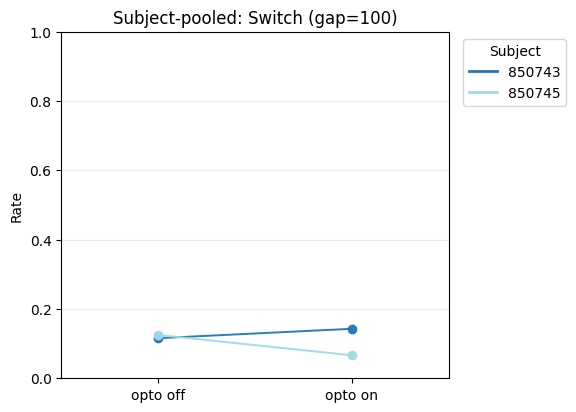

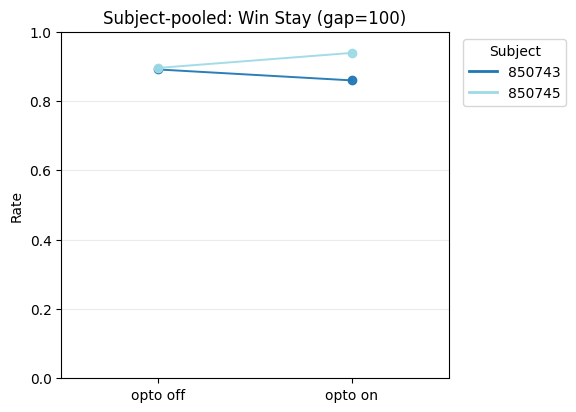

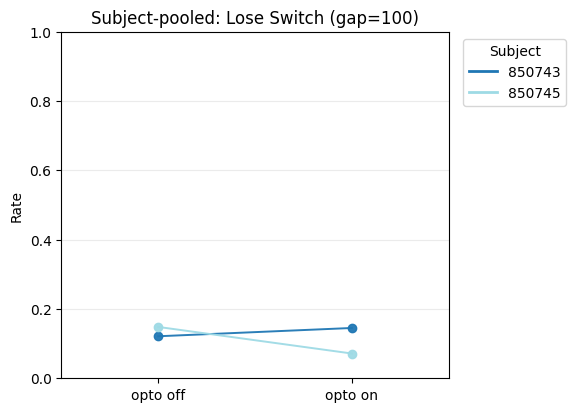

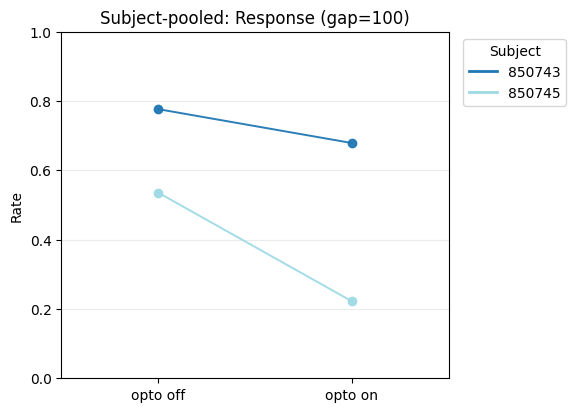

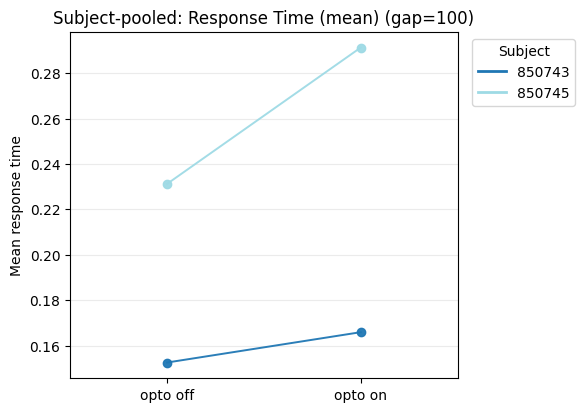

In [27]:
plot_on_off_block_rates(
    combined_dataframe,
    criteria=criteria,
    line_by='subject',
    #line_by='session',
    max_response_time=1,
    exclude_opto_trials=True
)

## Lick raster for opto trials and trial shifts

For the currently selected `criteria`, draw one raster panel per offset
(`offset=0` are the opto anchors themselves; `offset=±k` are the non-opto
trials k positions before/after each anchor within the same session).
Lick timestamps come straight from each session's behavior NWB
(`acquisition['left_lick_time']` / `acquisition['right_lick_time']`), so this
requires the NWB files to be available under the usual paths
(`/root/capsule/data/behavior_nwb`, `/root/capsule/data/optogenetics_nwb`).

[lick_raster] 84097 row(s), 183 session(s), 8823 opto trial(s) in dataframe after filters.
[lick_raster]   850743_2026-06-24_10-22-25: Found behavior NWB: /root/capsule/data/optogenetics_nwb/850743_2026-06-24_10-22-25.nwb
[lick_raster]   850743_2026-06-24_10-22-25: NWB clock probe
[lick_raster]     session_start_time = 2026-06-24 10:22:30.208483-07:00
[lick_raster]     timestamps_reference_time = 2026-06-24 10:22:30.208483-07:00
[lick_raster]     trials['goCue_start_time'] range=[3089226.04, 3093665.22] (n=500)
[lick_raster]     acquisition['FIP_falling_time'] range=[3089220.67, 3089220.67] n=1 ref=None
[lick_raster]     acquisition['FIP_rising_time'] range=[nan, nan] n=1 ref=None
[lick_raster]     acquisition['left_lick_time'] range=[3089226.42, 3094079.96] n=1891 ref=None <-- overlaps go-cue clock
[lick_raster]     acquisition['left_reward_delivery_time'] range=[3089232.25, 3093207.35] n=117 ref=None <-- overlaps go-cue clock
[lick_raster]     acquisition['optogenetics_time'] range=[

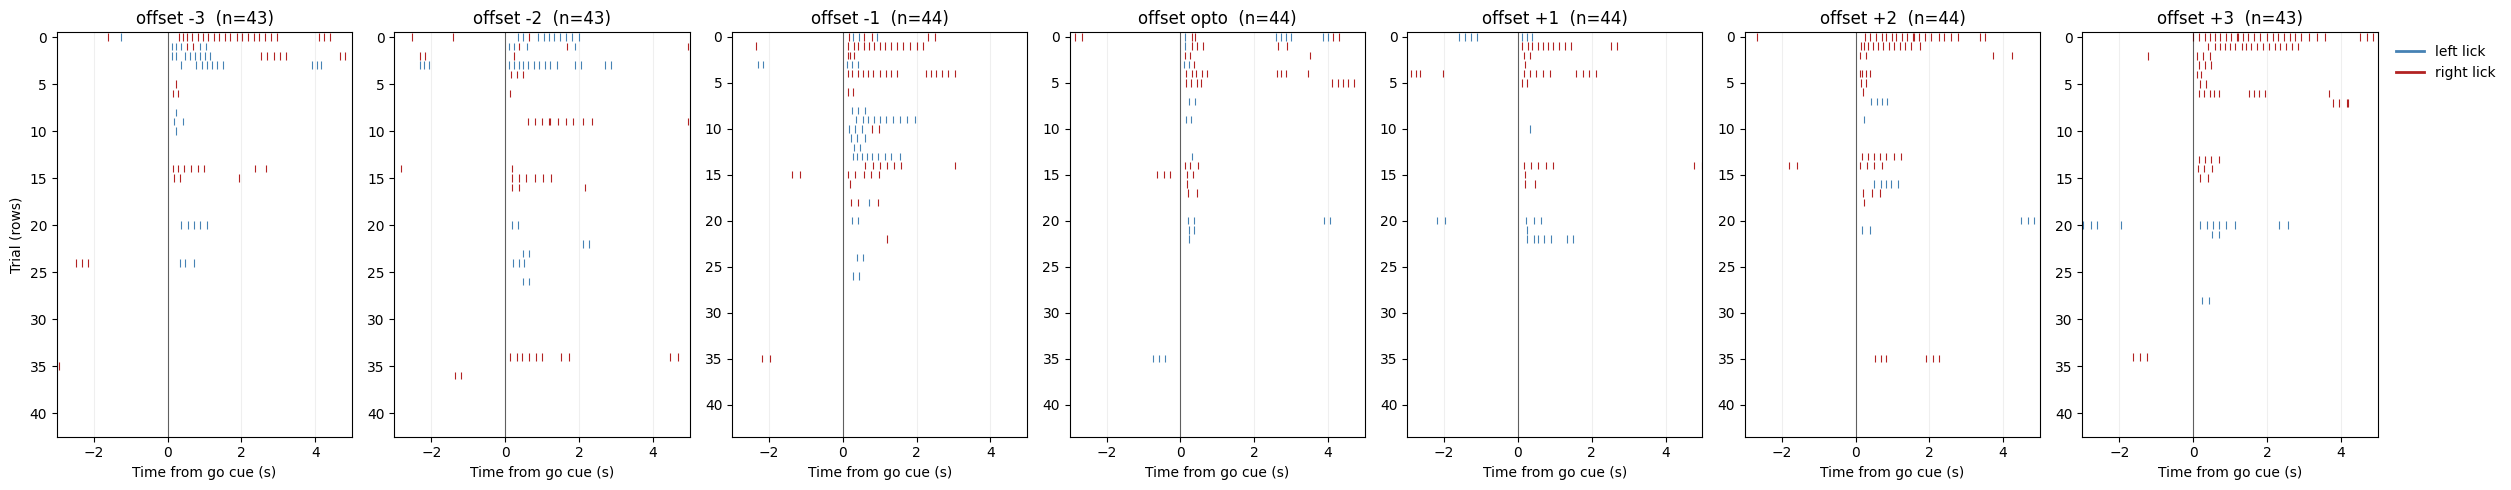

In [33]:
_ = plot_lick_raster_over_window(
    combined_dataframe,
    criteria=criteria,
    window=[-3, 3],
    peri_window=(-3, 5),
    sort_by="trial",
    # subject="...",          # optional: restrict to one subject
    # session="...",          # optional: restrict to one session
    # nwb_folder=[            # optional: override default search paths
    #     "/root/capsule/data/behavior_nwb",
    #     "/root/capsule/data/optogenetics_nwb",
    # ],
)